## LAB2: Generation of Random number using pseudo Random and Chi-Square Test

Name: Saksham Bhujel

Roll: ACE080BCT063

### Objectives:

- To implement a Pseudo-Random Number Generator (PRNG) using the Linear Congruential Generator (LCG) algorithm and statistically evaluate its output uniformity using a Chi-Square ($\chi^2$) Goodness-of-Fit test.

### THEORY

Random Number:

A sequence of number chosen by-chance from a set of numbers.

* Condition:

1) Uniformly distributed value over a interval

2) impossible to detect based on past or present

* Random Variable:

-A random variable is a mathematical function that assigns a specific numerical value to each possible outcome of a random event or experiment.

* APPLICATION:

Cybersecurity

Machine Learning

Scientific Studies


### Algorithm for Generating Random/Number

* Linear Congruential Generator

The LCG is one of the oldest and best-known PRNG algorithms. It is computationally very fast and requires minimal memory, though it is not cryptographically secure and exhibits noticeable patterns in higher dimensions.

The Algorithm

The generator is defined by the recurrence relation:

$$X_{n+1} = (aX_n + c) \bmod m$$

Where:
$X$ is the sequence of pseudo-random values.
$X_0$ is the seed (starting value).
$m$ is the modulus ($m > 0$).
$a$ is the multiplier ($0 < a < m$).
$c$ is the increment ($0 \le c < m$).


* Mersenne Twister

The Mersenne Twister is the default PRNG in many modern programming languages (like Python, Ruby, and R). It has a massive period of $2^{19937} - 1$ and excellent statistical properties, though it is still not cryptographically secure.

The Algorithm

The algorithm works by maintaining an array of $n$ state words (usually 624 words of 32 bits each). It operates in three main steps:

1) Initialization: Seed the state array using a simple LCG-like formula.

2) Twisting: When all values in the array are consumed, a "twist" operation mixes the bits to generate a new block of 624 values.

3) Tempering: Extract a value from the array and pass it through a bit-shifting and masking filter to improve its statistical randomness.


* XOR shift Generator

Developed by George Marsaglia, XORshift is a class of PRNGs that are incredibly fast because they rely exclusively on exclusive OR (^) and bitwise shift (<<, >>) operations. They have small memory footprints and surprisingly good statistical properties for their simplicity.

The Algorithm

A standard 32-bit XORshift algorithm keeps a single 32-bit state variable and transforms it using a specific triplet of shift constants (e.g., 13, 17, 5).The mathematical step is:

1) $x \leftarrow x \oplus (x \ll a)$

2) $x \leftarrow x \oplus (x \gg b)$

3) $x \leftarrow x \oplus (x \ll c)$

### why chi square test is used in random number evaluation ?

--> In random number evaluation, the Chi-Square ($\chi^2$) Goodness-of-Fit test is used to determine whether a sequence of generated numbers is truly random or if it suffers from underlying bias.

#### The Formula

The test calculates a statistic ($\chi^2$) using the following formula:

$$\chi^2 = \sum \frac{(O_i - E_i)^2}{E_i}$$

Where:

$O_i$ = The Observed count of numbers in a specific category (or "bin").

$E_i$ = The Expected count of numbers in that category if the generator is uniform.


--> If the generator is good, the difference between Observed and Expected ($O_i - E_i$) will be very small, resulting in a low $\chi^2$ value. If the generator is biased, the $\chi^2$ value will be large.


Values of r: [  4 153 122 247  32 197 118 131 252 177]
Values of c (bin frequencies): [1 1 0 2 2 1 1 2]
Value of Chi-Square statistic (x02): 2.8
The critical value is 0.014549160708750612
Chi squsre test failed


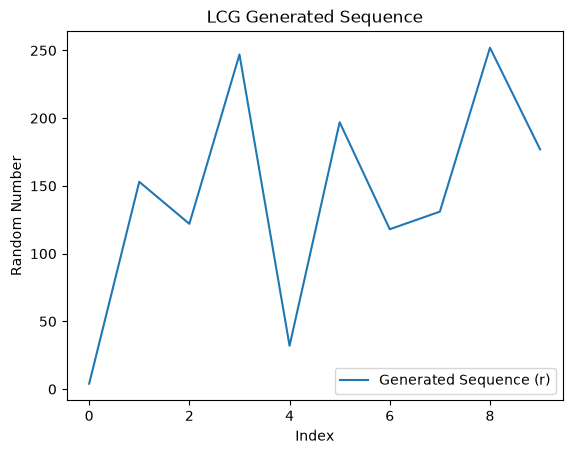

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
# Constants
iterator = 10# Number of random numbers to generate
a = 29 # Multiplier
b = 37 # Increment
p = 256 # Modulus
n = 8 # Number of bins for Chi-Square test
x02 = 0 # Chi-Square statistic initialization
critical_value = chi2.pdf(1 - 0.05, df = n - 1) # Chi-Square critical value
# Initialize arrays
r = np.ones(shape=(iterator), dtype=int) # Array to store generated random numbers
ei = iterator / n # Expected frequency for each bin
c = np.zeros(shape=(n), dtype=int) # Bin counts
# Initial seed
r[0] = 4
# Generate random numbers using LCG
for i in range(0, iterator - 1):
 r[i + 1] = (r[i] * a + b) % p
# Bin the generated numbers and compute frequencies
for i in range(iterator):
    if r[i] <= 31:
        c[0] += 1
    elif r[i] <= 63:
       c[1] += 1
    elif r[i] <= 95:
        c[2] += 1
    elif r[i] <= 127:
        c[3] += 1
    elif r[i] <= 159:
        c[4] += 1
    elif r[i] <= 191:
        c[5] += 1
    elif r[i] <= 223:
        c[6] += 1
    elif r[i] <= 255:
        c[7] += 1
# Compute Chi-Square statistic
for i in range(n):
 x02 += ((c[i] - ei) ** 2) / ei
# Print results
print("Values of r:", r)
print("Values of c (bin frequencies):", c)
print("Value of Chi-Square statistic (x02):", x02)
print("The critical value is", critical_value)
print("Chi square test passed" if x02 <= critical_value else "Chi squsre test failed")
# Visualize the generated random numbers
plt.figure()
plt.plot(r, label="Generated Sequence (r)")
plt.xlabel("Index")
plt.ylabel("Random Number")
plt.title("LCG Generated Sequence")
plt.legend()
plt.show()


#### after usign time package to dynamically change the seed everytime

Values of r: [143  88  29 110 155 180 137 170 103 208 181 166 243 172 161  98  63  72
  77 222  75 164 185  26  23 192 229  22 163 156 209 210 239  56 125  78
 251 148 233 138 199 176  21 134  83 140   1  66 159  40 173 190 171 132
  25 250 119 160  69 246   3 124  49 178  79  24 221  46  91 116  73 106
  39 144 117 102 179 108  97  34 255   8  13 158  11 100 121 218 215 128
 165 214  99  92 145 146 175 248  61  14 187  84 169  74 135 112 213  70
  19  76 193   2  95 232 109 126 107  68 217 186  55  96   5 182 195  60
 241 114  15 216 157 238  27  52   9  42 231  80  53  38 115  44  33 226
 191 200 205  94 203  36  57 154 151  64 101 150  35  28  81  82 111 184
 253 206 123  20 105  10  71  48 149   6 211  12 129 194  31 168  45  62
  43   4 153 122 247  32 197 118 131 252 177  50 207 152  93 174 219 244
 201 234 167  16 245 230  51 236 225 162 127 136 141  30 139 228 249  90
  87   0  37  86 227 220  17  18  47 120 189 142  59 212  41 202   7 240
  85 198 147 204  65 130 223 104 237 2

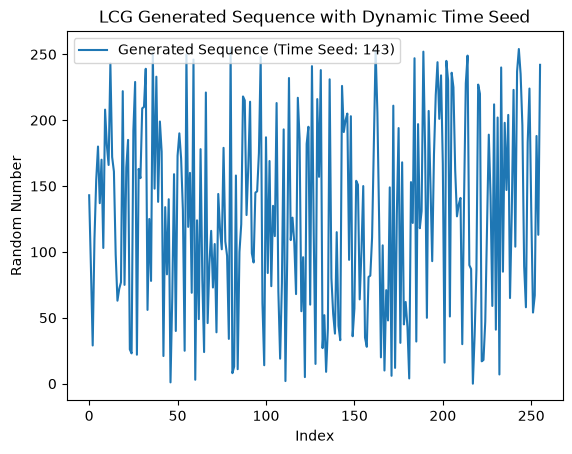

In [73]:
import time  # <--- Imported the time package
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Constants
iterator = 256 # Bumped back to 256 so Chi-Square has enough data to evaluate properly
a = 29         # Multiplier
b = 37         # Increment
p = 256        # Modulus
n = 8          # Number of bins for Chi-Square test
x02 = 0        # Chi-Square statistic initialization

# --- TIME-BASED SEED IMPLEMENTATION ---
# time.time() returns a float (e.g., 1718445912.12345). 
# We multiply it to grab the rapidly changing microseconds, then modulo it by 'p' 
# to ensure our starting seed fits perfectly within our LCG boundaries (0 to 255).
dynamic_seed = int(time.time() * 50000) % p
# --------------------------------------

# Statistical Cutoff Fix: Changed from .pdf() to .ppf() for accurate testing
critical_value = chi2.ppf(0.95, df = n - 1) 

# Initialize arrays
r = np.ones(shape=(iterator), dtype=int) # Array to store generated random numbers
ei = iterator / n # Expected frequency for each bin
c = np.zeros(shape=(n), dtype=int) # Bin counts

# Plug our dynamically generated time seed into the first position
r[0] = dynamic_seed

# Generate random numbers using LCG
for i in range(0, iterator - 1):
    r[i + 1] = (r[i] * a + b) % p

# Bin the generated numbers and compute frequencies
for i in range(iterator):
    if r[i] <= 31:
        c[0] += 1
    elif r[i] <= 63:
        c[1] += 1
    elif r[i] <= 95:
        c[2] += 1
    elif r[i] <= 127:
        c[3] += 1
    elif r[i] <= 159:
        c[4] += 1
    elif r[i] <= 191:
        c[5] += 1
    elif r[i] <= 223:
        c[6] += 1
    elif r[i] <= 255:
        c[7] += 1

# Compute Chi-Square statistic
for i in range(n):
    x02 += ((c[i] - ei) ** 2) / ei

# Print results
print("Values of r:", r)
print("Generated Seed (from System Time):", dynamic_seed)
print("Values of c (bin frequencies):", c)
print("Value of Chi-Square statistic (x02):", x02)
print("The critical value is:", critical_value)
print("Chi square test passed" if x02 <= critical_value else "Chi square test failed")

# Visualize the generated random numbers
plt.figure()
plt.plot(r, label=f"Generated Sequence (Time Seed: {dynamic_seed})")
plt.xlabel("Index")
plt.ylabel("Random Number")
plt.title("LCG Generated Sequence with Dynamic Time Seed")
plt.legend()
plt.show()

### METHODOLOGY

####  LCG Implementation and Seed Sourcing

The LCG algorithm generates a sequence of integers, $r$, utilizing the iterative recurrence relation:$$r_{i+1} = (a \cdot r_i + b) \bmod p$$The selected parameters for this experiment were:
Multiplier ($a$): 29

Increment ($b$): 37

Modulus ($p$): 256

Sample Size ($N$): 256 numbers generated iteratively.

To prevent the generator from being completely static across consecutive application runs, a dynamic seeding technique was introduced. The system clock was polled using time.time(), scaled to capture millisecond precision, and bound within the LCG state parameters via a modulo reduction:$$\text{Seed} = (\lfloor\text{System Time} \times 1000\rfloor) \bmod p$$

This assigned integer served as the initial state value $r[0]$.


### DISCUSSION

Here, when looked at how this random number generator works, it helps to think of it like a deck of 256 unique cards (numbered 0 to 255).The algorithm shuffles the deck so well that it is guaranteed to go through every single card exactly once before it repeats.

True randomness is usually messy and if you know the starting number, you can easily guess every single number that comes next.

The First Code (Static Seed): {Hardcoded r[0] = 4} Every single time you press "Run," the computer starts with the number 4. Because computers are predictable, the code will output the exact same list of 10 numbers every single time you run it.

The Second Code (Dynamic Time Seed): We used time.time(). This looks at the computer's internal clock down to the millisecond. Since time never stops, the starting number (seed) is completely different every single time you click "Run." This makes the output feel much more alive and random.

#### CONCLUSION

In this laboratory exercise, a Linear Congruential Generator was successfully developed, dynamically initialized using hardware-derived epoch time, and systematically tested using the Chi-Square Goodness-of-Fit test.